In [2]:
import flux_calc_parallel
import flux_variables
import thermalsyn_v2 as MQ24
import Constants as C

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap

In [3]:
# These below params should be altered to see the effects!
s = 1e5 # Effective range of magnetic field values B1/B0
a = 3.0 # Index for magnetic field probability distribution
delta = 1.0 # Index for explicit relation between post-shock number density and magnetic field strength

R = 1e16 # Undocumented... forward shock wave radius
BG = 0.01 # Shock proper velocity at R=R0 (the radius at which the maximum perpendicular 
          # extent of the shock is reached; see Figure 1 in FM25)
n0 = 1e3 # Nominal value for upstream number density
eps_e = 0.1 #eps_e = 0.000001 # Fraction of local fluid energy in power-law electrons
eps_B = 0.1 # Fraction of local fluid energy in magnetic field
eps_T = 0.4 # Fraction of local fluid energy in thermal electrons
p = 3.0 # Power-law electron distribution index
k = 0 # Power-law index for stratified density (Eq. 12 in FM25)
alpha = 0 # Power-law index for deceleration (Eq. 11 in FM25)

# These will flip flop, overlay both when altering the above
therm_el = True # If True---calculates thermal electron synchrotron flux
pl_el = True # If True---calculates power-law electron synchrotron flux

# These stay constant or are already known for a source
T = 50 # Time (days) of observation in observer's frame
mu_u = 0.62 # Mean molecular weight; nominal value 0.62
mu_e = 1.18 # Mean molecular weight per electron; nominal value 1.18
d_L = 10**28 # Luminosity distance (cm)
nu_res = 500 # Frequency array length
z = 0 # Source redshift

#nu_low, nu_high = 1e-2, 1e19 # Full EM range
nu_low, nu_high = 1e9, 1e12

# We set mu_u and mu_e to their defaults. 
# Event dependent info: d_L, T

# Things we could change but prob won't:
# eps_e, eps_T, k, alpha, s, delta

# Things we should def change (in accordance to Ross' advice):
# R, BG, n0, a, eps_B

In [4]:
def span_values(lo, hi, n=3, logspace=False):
    """ Pick n values spanning [lo, hi]. """
    if n == 1: return np.array([(lo + hi) / 2.0], dtype=float)

    elif logspace: return np.logspace(np.log10(lo), np.log10(hi), n)

    else: return np.linspace(lo, hi, n)

def compute_Lnu(params, therm_el, pl_el):
    nu = np.logspace(np.log10(params["nu_low"]), np.log10(params["nu_high"]), params["nu_res"])
    Lnu = flux_variables.L_ELOS_IHG(
        nu,
        params["s"], params["a"], params["delta"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["alpha"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return nu, Lnu

def compute_Lnu_R(params, therm_el, pl_el):
    nu = np.logspace(np.log10(params["nu_low"]), np.log10(params["nu_high"]), params["nu_res"])
    Lnu = flux_variables.LOS_IHG_Fitted_R(
        nu,
        params["s"], params["a"], params["delta"], params["R"],
        params["T"], params["n0"], params["eps_e"], params["eps_B"], params["eps_T"], params["p"],
        params["mu_u"], params["mu_e"],
        params["BG"], params["k"],
        params["d_L"], params["z"],
        therm_el=therm_el, pl_el=pl_el
    )
    return nu, Lnu

ranges = {
    "s":     (1e1, 1e6),
    "a":     (0.5, 4.0),
    "delta": (0.0, 3.0),
    "R":     (1e18, 1e20),
    "n0":    (1e-2, 1e8),
    "eps_e": (1e-10, 1e-1),
    "eps_B": (1e-6,  1.0),
    "eps_T": (1e-6,  1.0),
    "p":     (2.0, 4.0),
    "BG":    (0.01, 2),
    "k":     (0.0, 2.0),
    "alpha": (0.0, 3.0),
}

params_to_vary = list(ranges.keys())  # should be 12

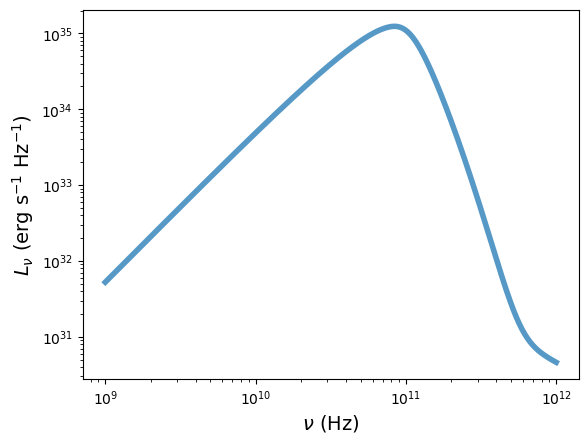

In [5]:
# s=1e5, a=0, delta=1
base = dict(
    s=1e5, a=0, delta=1.0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)

nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

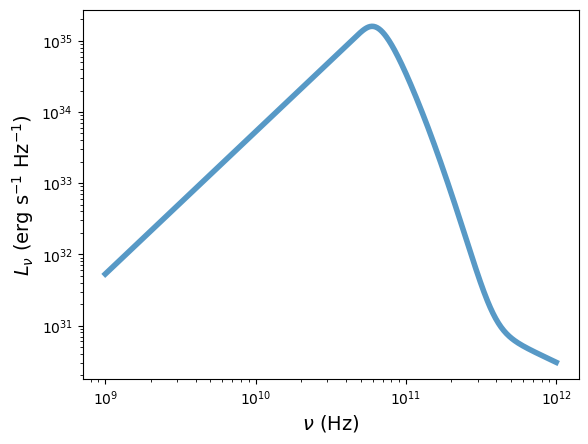

In [23]:
# s=1.1, a=3, delta=1
base = dict(
    s=1.1, a=3, delta=1.0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)
nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

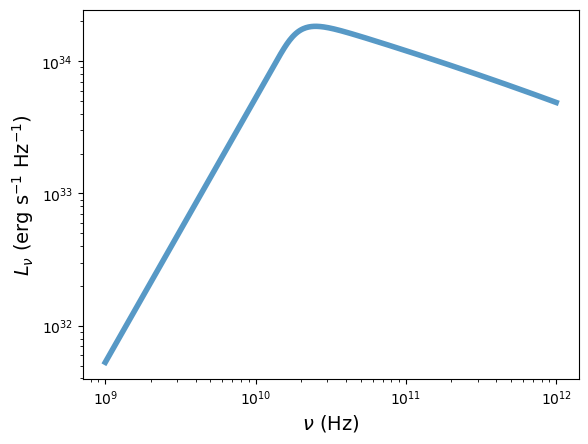

In [17]:
# s=1e5, a=3, delta=0
base = dict(
    s=1e5, a=3, delta=0, R=1e19,
    T=50, n0=1e3, eps_e=1e-6, eps_B=0.1, eps_T=0.4, p=3.0,
    BG=0.4, k=0.0, alpha=0.0,
    mu_u=0.62, mu_e=1.18, d_L=1e28, z=0.0,
    nu_res=500, nu_low=1e9, nu_high=1e12,
)

nu, Lnu = compute_Lnu_R(base, therm_el=True, pl_el=True)
plt.loglog(
    nu, Lnu,
    lw=4,
    alpha=0.75
)

plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
plt.show()

In [7]:
 def plot_param_sweep(param_name, lo, hi, nvals=3): # max 7 nvals please

    colors = ["red", "orange", "yellow", "green", "blue", "indigo", "violet"]
    vals = span_values(lo, hi, n=nvals)

    for ii, v in enumerate(vals):
        p = base.copy()
        p[param_name] = v

        nu, Lnu = compute_Lnu_R(p, therm_el=True, pl_el=True)

        plt.loglog(
            nu, Lnu,
            color=colors[ii],
            lw=4,
            alpha=0.75,
            label=f"{param_name} = {v:g}"
        )

    plt.title(f"Vary {param_name}: [{lo}, {hi}]", fontsize=14)
    plt.xlabel(r"$\nu$ (Hz)", fontsize=14)
    plt.ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=14)
    plt.legend()
    plt.show()

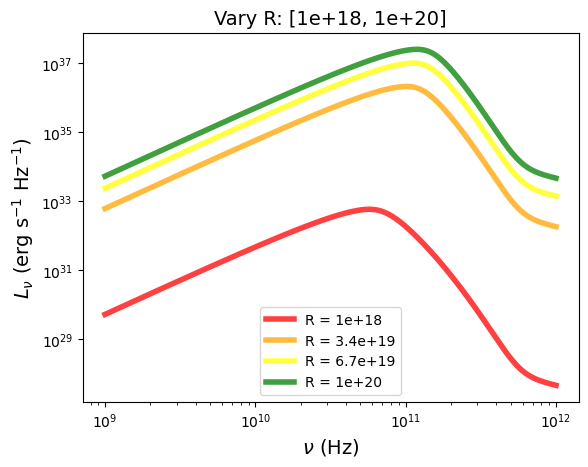

In [8]:
plot_param_sweep("R", 1e18, 1e20, nvals=4)

In [10]:
def plot_param_sweep_ax(ax, param_name, lo, hi, nvals=3, therm_el=True, pl_el=True, default=True):

    colors = ["red", "orange", "yellow", "green", "blue", "indigo", "violet"]
    logParams = ["s", "R", "n0", "eps_e", "eps_B", "eps_B"]
    if param_name in logParams: log = True
    else: log = False
    vals = span_values(lo, hi, n=nvals, logspace=log)

    for ii, v in enumerate(vals):
        p = base.copy()
        p[param_name] = v
        try:
            if default: nu, Lnu = compute_Lnu(p, therm_el=therm_el, pl_el=pl_el)
            else: nu, Lnu = compute_Lnu_R(p, therm_el=therm_el, pl_el=pl_el)
        except ZeroDivisionError:
            print(f'{param_name}={v:g} causes an error')
            continue
        ax.loglog(nu, Lnu, lw=2.5, alpha=0.75, color=colors[ii], label=f"{param_name} = {v:g}")

    ax.legend()
    ax.set_title(f"{param_name}", fontsize=11)
    ax.set_xlabel(r"$\nu$ (Hz)", fontsize=10)
    ax.set_ylabel(r"$L_\nu$ (erg s$^{-1}$ Hz$^{-1}$)", fontsize=10)

def plot_collage(param_names, ranges, nvals=3, therm_el=True, pl_el=True, default=True):

    fig, axes = plt.subplots(1, len(params_to_vary), figsize=(16,4), constrained_layout=True)
    axes = axes.ravel()

    for i, param_name in enumerate(params_to_vary):
        lo, hi = ranges[param_name]
        plot_param_sweep_ax(
            axes[i], param_name, lo, hi,
            nvals=nvals,
            therm_el=therm_el, pl_el=pl_el,
            default=default
        )

    return fig, axes

param_names = list(ranges.keys())

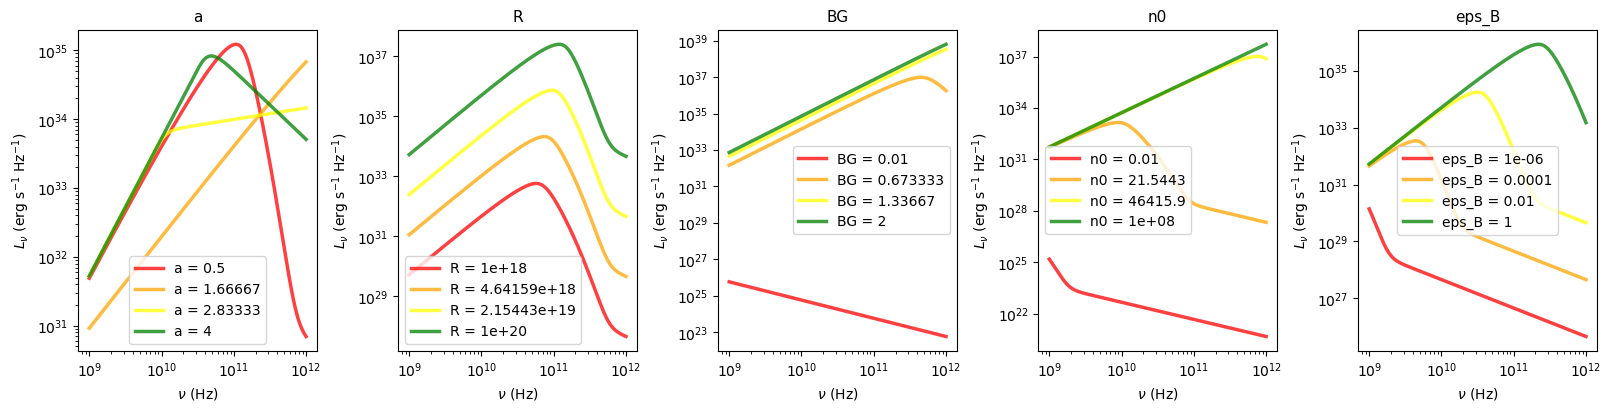

In [11]:
params_to_vary = ["a","R","BG","n0","eps_B"]
fig, axes = plot_collage(param_names, ranges, nvals=4, therm_el=True, pl_el=True, default=False)
plt.show()

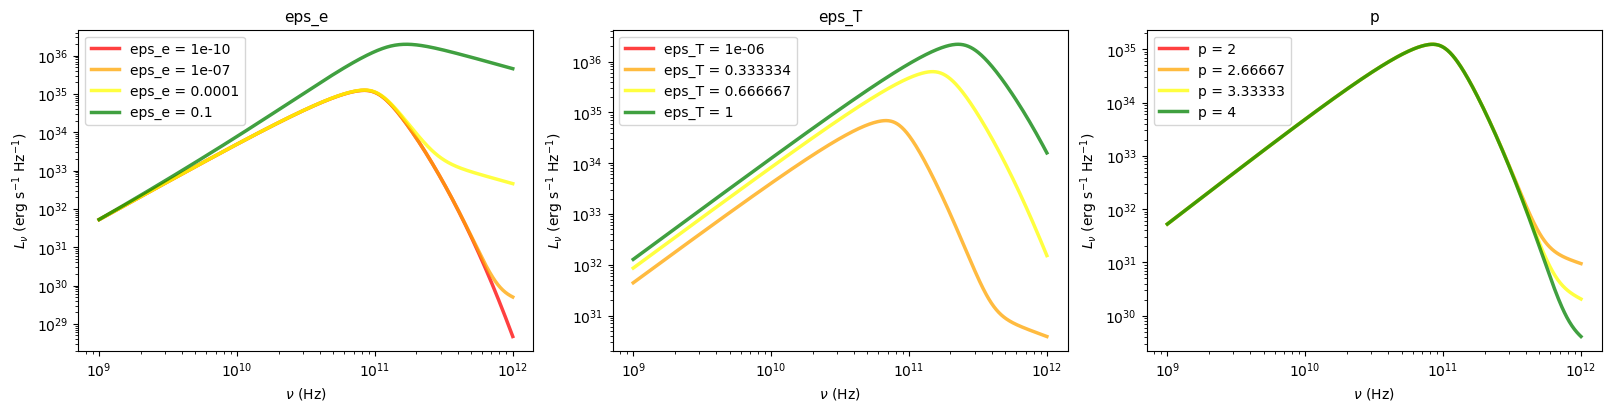

In [12]:
params_to_vary = ["eps_e","eps_T","p"]
fig, axes = plot_collage(param_names, ranges, nvals=4, therm_el=True, pl_el=True, default=False)
plt.show()

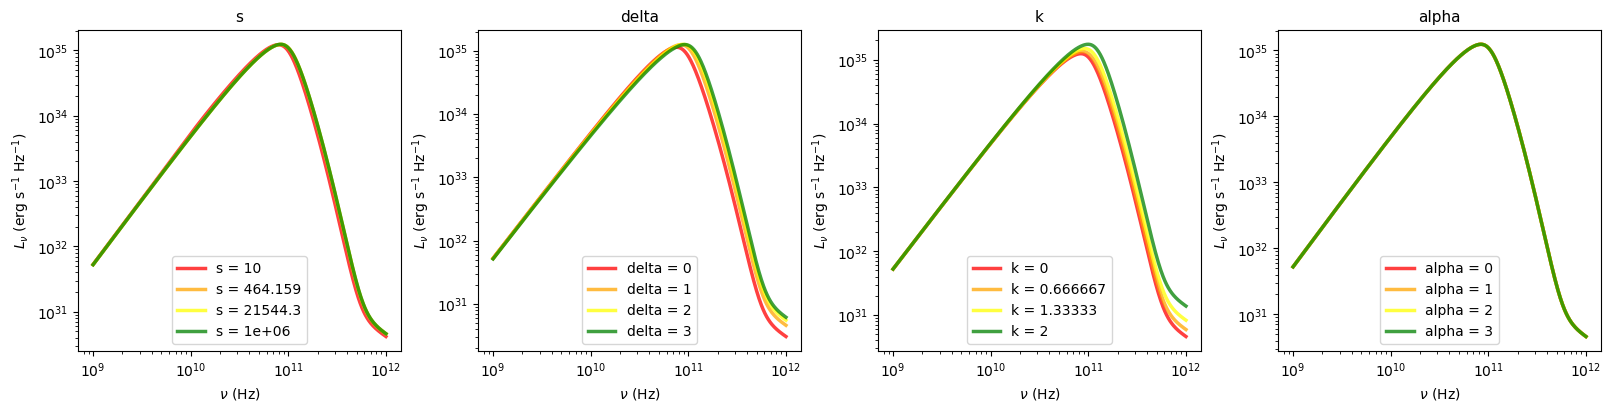

In [13]:
params_to_vary = ["s","delta","k","alpha"]
fig, axes = plot_collage(param_names, ranges, nvals=4, therm_el=True, pl_el=True, default=False)
plt.show()